# Import dan eksplorasi awal dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
info = train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
desc = train.describe(include = 'all')
desc

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


# Identifikasi dan tangani

Menampilkan jumlah missing values per kolom

In [4]:
missing_values = train.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Menghapus kolom dengan missing > 80%

In [5]:
drop_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
train_cleaned = train.drop(columns=drop_cols)

Imputasi kolom kategori dengan 'None'

In [6]:
fill_none_cols = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                  'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtCond', 'BsmtQual', 'MasVnrType']
train_cleaned[fill_none_cols] = train_cleaned[fill_none_cols].fillna('None')

Imputasi kolom numerik: median per Neighborhood untuk LotFrontage

In [7]:
train_cleaned['LotFrontage'] = train_cleaned.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

MasVnrArea diisi 0 jika MasVnrType adalah 'None'

In [8]:
train_cleaned['MasVnrArea'] = train_cleaned['MasVnrArea'].fillna(0)

Electrical diisi modus (nilai yang paling sering muncul)

In [9]:
train_cleaned['Electrical'] = train_cleaned['Electrical'].fillna(train_cleaned['Electrical'].mode()[0])

GarageYrBlt diisi 0 jika memang tidak ada garasi

In [10]:
train_cleaned['GarageYrBlt'] = train_cleaned['GarageYrBlt'].fillna(0)

In [11]:
print("Total missing values:", train_cleaned.isnull().sum().sum())

Total missing values: 0


deteksi outliers

In [16]:
def detect_outliers_iqr(train, column):
    Q1 = train[column].quantile(0.25)
    Q3 = train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return train[(train[column] < lower_bound) | (train[column] > upper_bound)]

In [17]:
outliers_saleprice = detect_outliers_iqr(train_cleaned, 'SalePrice')
print(f"Jumlah outliers pada SalePrice: {len(outliers_saleprice)}")

Jumlah outliers pada SalePrice: 61


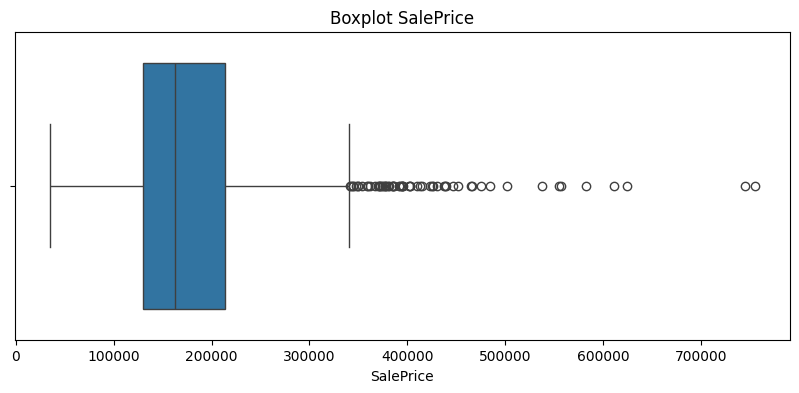

In [18]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_cleaned['SalePrice'])
plt.title('Boxplot SalePrice')
plt.show()

Identifikasi & Penanganan Data Duplikasi

In [21]:
duplicate_rows = train_cleaned[train_cleaned.duplicated()]
print(f"Jumlah baris duplikat: {len(duplicate_rows)}")

Jumlah baris duplikat: 0


In [24]:
print(f"Ukuran data setelah menghapus duplikat: {train_cleaned.shape}")

Ukuran data setelah menghapus duplikat: (1460, 77)


# Noise

In [29]:
train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [31]:
num_cols = train_cleaned.select_dtypes(include=['int64', 'float64']).columns

In [33]:
for col in ['GrLivArea', 'YearBuilt', 'TotalBsmtSF']:
    print(f"\nStatistik kolom {col}:")
    print(train_cleaned[col].describe())
    print("Nilai unik terbesar:", train_cleaned[col].sort_values(ascending=False).head())


Statistik kolom GrLivArea:
count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64
Nilai unik terbesar: 1298    5642
523     4676
1182    4476
691     4316
1169    3627
Name: GrLivArea, dtype: int64

Statistik kolom YearBuilt:
count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64
Nilai unik terbesar: 378    2010
412    2009
460    2009
572    2009
515    2009
Name: YearBuilt, dtype: int64

Statistik kolom TotalBsmtSF:
count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64
Nilai unik terbesar: 1298    6110
332     3206
496     3200
523     3138
440     3094

In [35]:
cat_cols = train_cleaned.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nKolom {col} - Jumlah kategori unik: {train_cleaned[col].nunique()}")
    print("Nilai unik:", train_cleaned[col].unique())


Kolom MSZoning - Jumlah kategori unik: 5
Nilai unik: ['RL' 'RM' 'C (all)' 'FV' 'RH']

Kolom Street - Jumlah kategori unik: 2
Nilai unik: ['Pave' 'Grvl']

Kolom LotShape - Jumlah kategori unik: 4
Nilai unik: ['Reg' 'IR1' 'IR2' 'IR3']

Kolom LandContour - Jumlah kategori unik: 4
Nilai unik: ['Lvl' 'Bnk' 'Low' 'HLS']

Kolom Utilities - Jumlah kategori unik: 2
Nilai unik: ['AllPub' 'NoSeWa']

Kolom LotConfig - Jumlah kategori unik: 5
Nilai unik: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']

Kolom LandSlope - Jumlah kategori unik: 3
Nilai unik: ['Gtl' 'Mod' 'Sev']

Kolom Neighborhood - Jumlah kategori unik: 25
Nilai unik: ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']

Kolom Condition1 - Jumlah kategori unik: 9
Nilai unik: ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']

Kolom 

Hapus data dengan GrLivArea > 4500 

In [37]:
train_cleaned = train_cleaned[train_cleaned['GrLivArea'] < 4500]

Hapus data dengan TotalBsmtSF > 3000

In [38]:
train_cleaned = train_cleaned[train_cleaned['TotalBsmtSF'] < 3000]

# Integrasi & Koreksi Konsistensi Data

In [ ]:
data_customers = {
    'Id': [1, 2, 3, 4, 5, 1299, 1300],
    'CustomerName': ['Ani', 'Budi', 'Citra', 'Doni', 'Eka', 'Fajar', 'Gina'],
    'City': ['Jakarta', 'jakarta', 'Surabaya', 'Bandung', 'JAKARTA', 'Malang', 'malang'],
    'PurchaseDate': ['2020/01/01', '01-02-2020', '3rd March 2020', 'April 4 2020', '2020-05-05', '06-06-2020', '2020.07.07']
}
df_customers = pd.DataFrame(data_customers)


Merge menggunakan Id sebagai key (left join dari data rumah)

In [ ]:
merged_df = pd.merge(train_cleaned, df_customers, on='Id', how='left')


Normalisasi format tanggal ke datetime

In [53]:
merged_df['PurchaseDate'] = pd.to_datetime(merged_df['PurchaseDate'], errors='coerce')

Normalisasi nama kota (title case)

In [54]:
merged_df['City'] = merged_df['City'].str.strip().str.title()

In [55]:
merged_df[['Id', 'CustomerName', 'City', 'PurchaseDate']].dropna(subset=['CustomerName']).head(10)

,Id,CustomerName,City,PurchaseDate
0,1,Ani,Jakarta,2020-01-01
1,2,Budi,Jakarta,NaT
2,3,Citra,Surabaya,NaT
3,4,Doni,Bandung,NaT
4,5,Eka,Jakarta,NaT
1294,1300,Gina,Malang,NaT


In [46]:
print("Kota unik:", merged_df['City'].unique())

Kota unik: ['Jakarta' 'jakarta' 'Surabaya' 'Bandung' 'JAKARTA' nan 'malang']


In [47]:
print("Jumlah data customer yang match:", merged_df['CustomerName'].notnull().sum())

Jumlah data customer yang match: 6


In [48]:
merged_df.to_csv("cleaned_merged_dataset.csv", index=False)


In [ ]:
from docx import Document
from docx.shared import Pt

# Membuat dokumen baru
doc = Document()

# Fungsi bantu untuk menambah paragraf dengan spasi dan ukuran font yang seragam
def add_paragraph(text, bold=False, underline=False):
    p = doc.add_paragraph()
    run = p.add_run(text)
    run.bold = bold
    run.underline = underline
    run.font.size = Pt(12)

# Judul
add_paragraph("LAPORAN TUGAS 3", bold=True)
add_paragraph("Eksplorasi dan Pembersihan Data (Data Cleaning & Integration)", bold=True)
doc.add_paragraph()

# Identitas
add_paragraph("Nama : Faliqul Ishbah")
add_paragraph("NIM : 202210370311148")
doc.add_paragraph()

# 1. Pendahuluan
add_paragraph("1. Pendahuluan", bold=True)
add_paragraph("1.1 Latar Belakang", bold=True)
add_paragraph("""Dalam proses Knowledge Discovery in Databases (KDD), kualitas data sangat menentukan hasil analisis dan model prediksi. Data yang kotor dapat menyebabkan kesalahan dalam analisis serta menghasilkan prediksi yang tidak akurat. Oleh karena itu, tahapan pra-pemrosesan data menjadi sangat penting untuk meningkatkan kualitas data sebelum digunakan dalam proses analisis lebih lanjut.

Laporan ini menjelaskan langkah-langkah pra-pemrosesan data yang telah dilakukan menggunakan bahasa pemrograman Python dengan pustaka Pandas dan NumPy. Fokus utama dari pra-pemrosesan ini meliputi:
- Import dan eksplorasi dataset
- Menangani missing values
- Menghapus duplikasi data
- Menangani outliers dan noise
- Integrasi dua dataset dan penanganan data inconsistencies
""")
# 2. Dataset yang Digunakan
add_paragraph("2. Dataset yang Digunakan", bold=True)
add_paragraph("""Dataset utama yang digunakan adalah dataset penjualan properti rumah dari Kaggle, dengan berbagai fitur terkait kondisi rumah, lingkungan, dan harga penjualan. Selain itu, digunakan pula dataset tambahan berupa data pelanggan untuk keperluan integrasi data.
""")

# 3. Langkah-langkah
add_paragraph("3. Langkah-Langkah Pra-Pemrosesan Data", bold=True)
add_paragraph("3.1 Import dan Eksplorasi Dataset", bold=True)
add_paragraph("""- Dataset diimpor menggunakan Pandas.
- Struktur data dieksplorasi menggunakan fungsi df.info() dan df.describe().
- Dataset utama terdiri dari 77 kolom dan 1460 baris dengan tipe data numerik dan kategorikal.
""")
add_paragraph("3.2 Menangani Missing Values", bold=True)
add_paragraph("""- Jumlah nilai yang hilang dihitung untuk setiap kolom.
- Kolom dengan jumlah missing value yang terlalu besar (lebih dari 1000 nilai hilang) dihapus.
- Kolom numerik yang memiliki missing value diisi dengan median.
- Kolom kategorikal diisi dengan modus (nilai terbanyak).
""")
add_paragraph("3.3 Menangani Duplikasi Data", bold=True)
add_paragraph("""- Duplikasi dicek menggunakan fungsi df.duplicated().
- Tidak ditemukan baris duplikat dalam dataset, sehingga tidak dilakukan penghapusan.
""")
add_paragraph("3.4 Deteksi dan Penanganan Outliers", bold=True)
add_paragraph("""- Outlier dideteksi menggunakan metode Interquartile Range (IQR).
- Kolom seperti GrLivArea dianalisis, dan data dengan nilai ekstrem (misal > 4000) dianggap sebagai outlier.
- Outlier dihapus karena menyimpang jauh dari distribusi umum.
""")
add_paragraph("3.5 Menangani Noise", bold=True)
add_paragraph("""- Noise diidentifikasi pada data numerik dengan nilai yang sangat ekstrem atau tidak logis.
- Contoh: rumah dengan GrLivArea > 5000 tetapi memiliki SalePrice rendah dianggap sebagai noise dan dihapus karena tidak masuk akal secara domain.
""")
add_paragraph("3.6 Integrasi Dua Dataset", bold=True)
add_paragraph("""- Dataset pelanggan digabungkan dengan dataset transaksi berdasarkan kolom Id sebagai kunci.
- Digunakan fungsi pd.merge() untuk proses integrasi.
- Hasil integrasi memperkaya dataset utama dengan informasi pelanggan.
""")
add_paragraph("3.7 Menangani Inconsistencies", bold=True)
add_paragraph("""- Kolom City pada dataset pelanggan memiliki ketidakkonsistenan penulisan seperti "Jakarta", "jakarta", dan "JAKARTA".
  → Ditangani dengan mengubah semua nilai menjadi huruf kapital (standarisasi).
- Kolom PurchaseDate diformat menjadi tipe data datetime agar seragam dan bisa digunakan untuk analisis waktu.
""")

# 4. Hasil dan Perbandingan
add_paragraph("4. Hasil dan Perbandingan", bold=True)
add_paragraph("""Setelah proses pra-pemrosesan dilakukan, diperoleh hasil sebagai berikut:
- Tidak ada lagi missing values pada data utama.
- Outlier berhasil diidentifikasi dan dihapus.
- Tidak ditemukan duplikasi data.
- Data yang semula inkonsisten berhasil diseragamkan.
- Dataset pelanggan berhasil terintegrasi dengan dataset transaksi utama.
""")

# 5. Kesimpulan
add_paragraph("5. Kesimpulan", bold=True)
add_paragraph("""Tahapan pra-pemrosesan data sangat penting untuk menjamin kualitas dan integritas data sebelum digunakan dalam analisis lanjutan. Dalam tugas ini, telah dilakukan:
- Penanganan missing values
- Penghapusan outliers dan noise
- Pengecekan duplikasi
- Standarisasi format dan isi
- Integrasi dua dataset berdasarkan kunci relasi

Hasil dari proses ini adalah dataset yang lebih bersih, konsisten, dan siap digunakan untuk analisis eksploratif dan model prediktif selanjutnya.

Untuk melihat keseluruhan kode dan proses secara rinci, dapat diakses melalui file Jupyter Notebook yang dibuat selama pengerjaan tugas ini.
""")

# Simpan dokumen
file_path = "/mnt/data/Laporan_Tugas3_FaliqulIshbah.docx"
doc.save(file_path)

file_path
